In [1]:
import numpy as np
import pandas as pd
from numpy.fft import fft
from matplotlib import pyplot as plt
import math
import warnings,os
import glob
warnings.filterwarnings('ignore')

# Gather Data points
1. Given path of the folder that contain all labels folder 
2. Each label folder contain same amount of data point file and name as output_1.csv ....output_*.csv
3. Gather all datapoints to all_result in each labels' folder.

In [6]:
path="./data/2025-2-25-internal/train_set/cylinder_3/"
folder_list = os.listdir(path)

In [8]:
file_size=100
def get_data(raw_data):
  data=raw_data.drop(["msg"],axis=1)
  rot_data = data
  return rot_data
# concate all data to single file
for name_idx in range(len(folder_list)):
  df=[]
  for i in range(1,file_size+1):
    material=path+folder_list[name_idx]
    filename="/output_"+str(i)+".csv"
    temp=pd.read_csv(material+filename)
    temp=get_data(temp) # remove the unuse columns
    row_data=[]
    for row in range (len(temp)):
      row_data.append(temp.iloc[row].values)
    row_data=np.array(row_data).reshape((1,-1)).squeeze(axis=0)
    df.append(row_data)
  df=pd.DataFrame(df)
  material=path+folder_list[name_idx]
  df.transpose().to_csv(material+"/all_result.csv")
  print("finish "+folder_list[name_idx])

finishp13
finishp7
finishp3
finishp6
finishp17
finishp1
finishp15
finishp18
finishp2
finishp10
finishp16
finishp19
finishp4
finishp14
finishp5
finishp12
finishp11
finishp8
finishp9


# Trianing

## Import dataset


In [2]:
import random
def import_data(name,path):
  """
  Import the data from the CSV file.
    
    Args:
        name (str): The name of the folder.
        path (str): The path of the folder.

    Returns:
        pd.DataFrame: A dataframe containing the data.
  """
  material=path+name
  filename="/all_result.csv"
  df=pd.read_csv(material+filename)
  df=df.dropna(axis=0) # drop the unconsistent data long
  df=df.drop(list(df)[0],axis=1)
  return df

In [3]:
path="./data/2025-2-25-internal/train_set/cylinder_3/"
folder_list = os.listdir(path)

In [4]:
df_all=pd.DataFrame()
start=1
end=19
labellist=['p'+str(i) for i in range(start,end)]
gap_list=[ "p4", "p8", "p12", "p16"]
for name in folder_list:
  df_temp=import_data(name=name,path=path)
  label=""
  for i in labellist:
    if i == name :
      label=i
      break
  if label=="" :
    continue
  df_temp.loc['label']=[(labellist.index(label)+start-1)*(1/18) for _ in list(df_temp)]
  print(df_temp.loc['label'][0],name)
  df_all = pd.concat([df_all, df_temp], axis=1)


0.6666666666666666 p13
0.3333333333333333 p7
0.1111111111111111 p3
0.2777777777777778 p6
0.8888888888888888 p17
0.0 p1
0.7777777777777777 p15
0.9444444444444444 p18
0.05555555555555555 p2
0.5 p10
0.8333333333333333 p16
0.16666666666666666 p4
0.7222222222222222 p14
0.2222222222222222 p5
0.611111111111111 p12
0.5555555555555556 p11
0.38888888888888884 p8
0.4444444444444444 p9


In [5]:
df_all2=pd.DataFrame()
path_2="./data/2025-2-25-internal/test_set/cylinder_3/"
folder_list_2 = os.listdir(path_2)
for name in folder_list_2:
  # if(name!="p1"):continue
  df_temp=import_data(name=name,path=path_2)
  label=""
  for i in labellist:
    if i == name :
      label=i
      break
  if label=="":
    continue
  # print(label,name)
  df_temp.loc['label']=[(labellist.index(label)+start-1)*(1/18) for _ in list(df_temp)]
  print(df_temp.loc['label'][0],name)
  df_all2 = pd.concat([df_all2, df_temp], axis=1,ignore_index=True)

0.6666666666666666 p13
0.3333333333333333 p7
0.1111111111111111 p3
0.2777777777777778 p6
0.8888888888888888 p17
0.0 p1
0.7777777777777777 p15
0.9444444444444444 p18
0.05555555555555555 p2
0.5 p10
0.8333333333333333 p16
0.16666666666666666 p4
0.7222222222222222 p14
0.2222222222222222 p5
0.611111111111111 p12
0.5555555555555556 p11
0.38888888888888884 p8
0.4444444444444444 p9


In [6]:
df_all=df_all.dropna(axis=0)
df_all = pd.concat([df_all.iloc[:42000], df_all.iloc[[-1]]], axis=0,ignore_index = True)

df_all2=df_all2.dropna(axis=0)
df_all2 = pd.concat([df_all2.iloc[:42000], df_all2.iloc[[-1]]], axis=0,ignore_index = True)

In [7]:
def fft_self(df):
    data_rows = df.iloc[:-1, :]  # All rows except the last
    label_row = df.iloc[-1, :]    # Last row (label)

    # Apply FFT on each column except the last row
    fft_result = data_rows.apply(lambda col: np.abs(np.fft.fft(col)), axis=0)

    # Append the label row to the FFT result
    fft_result.loc['label'] = label_row
    return fft_result

In [8]:
df_all=fft_self(df_all)
df_all2=fft_self(df_all2)

In [221]:
df_all

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,3236.000000,20475.000000,22178.000000,19748.000000,20319.000000,6755.000000,18629.000000,20436.000000,20339.000000,21589.000000,...,14764.000000,18696.000000,21536.000000,20582.000000,22960.000000,16473.000000,18804.000000,20600.000000,22715.000000,19780.000000
1,16969.230782,2129.386938,1099.000667,578.608921,2097.060329,25550.574892,1191.133219,513.122301,1194.159374,1712.161492,...,1674.403863,910.326502,1319.217746,121.539897,1448.163029,3406.965467,776.299727,867.771133,2509.101058,1991.676903
2,23075.549807,1747.965567,1160.067895,4401.236499,3607.075138,22927.812847,2854.949285,3810.155065,1994.910925,4777.719875,...,1019.313387,413.382120,2255.978614,2155.655794,3846.987953,968.552188,4262.357063,920.584283,3918.034671,3103.007536
3,31846.047704,4170.441562,3250.173438,3357.151839,2199.475718,25392.382720,2107.689797,4452.424049,1253.785759,1455.492798,...,2663.417080,996.319561,2177.567473,2924.536007,1223.575073,2203.471578,1288.281382,1248.630309,3742.610285,1634.106394
4,32879.922807,1965.763003,4921.447835,4175.049130,1452.951735,29100.734910,1756.257164,1202.530329,1303.792773,3641.784563,...,4197.460365,3919.715697,2684.051560,963.658505,2437.216494,3346.894788,589.656866,2614.383001,3478.528514,818.002729
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41996,32879.922807,1965.763003,4921.447835,4175.049130,1452.951735,29100.734910,1756.257164,1202.530329,1303.792773,3641.784563,...,4197.460365,3919.715697,2684.051560,963.658505,2437.216494,3346.894788,589.656866,2614.383001,3478.528514,818.002729
41997,31846.047704,4170.441562,3250.173438,3357.151839,2199.475718,25392.382720,2107.689797,4452.424049,1253.785759,1455.492798,...,2663.417080,996.319561,2177.567473,2924.536007,1223.575073,2203.471578,1288.281382,1248.630309,3742.610285,1634.106394
41998,23075.549807,1747.965567,1160.067895,4401.236499,3607.075138,22927.812847,2854.949285,3810.155065,1994.910925,4777.719875,...,1019.313387,413.382120,2255.978614,2155.655794,3846.987953,968.552188,4262.357063,920.584283,3918.034671,3103.007536
41999,16969.230782,2129.386938,1099.000667,578.608921,2097.060329,25550.574892,1191.133219,513.122301,1194.159374,1712.161492,...,1674.403863,910.326502,1319.217746,121.539897,1448.163029,3406.965467,776.299727,867.771133,2509.101058,1991.676903


In [222]:
df_all2

,0,1,2,3,4,5,6,7,8,9,...,440,441,442,443,444,445,446,447,448,449
0,11186.000000,16221.000000,18302.000000,20307.000000,20821.000000,32875.000000,20289.000000,23485.000000,23651.000000,20992.000000,...,15640.000000,21952.000000,23187.000000,18829.000000,20482.000000,11966.000000,20092.000000,20334.000000,21238.000000,23533.000000
1,4205.261758,3173.646136,2823.784337,921.867232,2112.402336,29413.674711,7492.368363,9110.052965,2890.448908,1904.097683,...,2867.345009,1869.891483,5168.298230,2369.393107,2338.619211,1627.230794,2040.288065,1495.729430,2111.107747,4919.172558
2,1120.571009,5067.662881,3506.395696,2439.579721,1183.934990,21512.482578,13715.909055,18910.509221,2763.590106,1967.853746,...,3577.528052,1361.106113,765.729375,3917.916071,3139.715872,1172.291717,617.321975,1790.941068,2086.032147,3946.281042
3,2928.630106,4604.937497,3850.832285,1481.319549,2807.483310,78173.779358,21049.196613,22614.428886,6508.404055,1866.247530,...,4976.946699,2969.839437,1566.691636,1322.073806,2977.320576,674.246072,1793.096152,3539.080087,3111.656688,7426.114495
4,5810.431815,5400.738468,2628.730949,628.748281,1430.983844,26581.149143,20657.237908,31085.014248,2364.252997,420.265707,...,3129.286245,3088.991007,2450.419647,2953.163030,3101.506507,1748.083009,660.686507,2924.354567,2804.833161,5032.302348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41996,5810.431815,5400.738468,2628.730949,628.748281,1430.983844,26581.149143,20657.237908,31085.014248,2364.252997,420.265707,...,3129.286245,3088.991007,2450.419647,2953.163030,3101.506507,1748.083009,660.686507,2924.354567,2804.833161,5032.302348
41997,2928.630106,4604.937497,3850.832285,1481.319549,2807.483310,78173.779358,21049.196613,22614.428886,6508.404055,1866.247530,...,4976.946699,2969.839437,1566.691636,1322.073806,2977.320576,674.246072,1793.096152,3539.080087,3111.656688,7426.114495
41998,1120.571009,5067.662881,3506.395696,2439.579721,1183.934990,21512.482578,13715.909055,18910.509221,2763.590106,1967.853746,...,3577.528052,1361.106113,765.729375,3917.916071,3139.715872,1172.291717,617.321975,1790.941068,2086.032147,3946.281042
41999,4205.261758,3173.646136,2823.784337,921.867232,2112.402336,29413.674711,7492.368363,9110.052965,2890.448908,1904.097683,...,2867.345009,1869.891483,5168.298230,2369.393107,2338.619211,1627.230794,2040.288065,1495.729430,2111.107747,4919.172558


In [9]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import KernelPCA
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
from sklearn import datasets, linear_model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import  r2_score,root_mean_squared_error,mean_absolute_error

In [10]:
df = df_all.T
X=df.drop("label",axis=1)
y=df["label"]
df2 = df_all2.T
X2=df2.drop("label",axis=1)
y2=df2["label"]
X.shape,y.shape,X2.shape,y2.shape

((1800, 42000), (1800,), (450, 42000), (450,))

In [11]:
# n_schedule=[809,500,100,50,25,10,5,3,2]
n_schedule=[9,8,7,6]
for i in n_schedule:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=32)

    # Create linear regression object
    # regr =GradientBoostingRegressor(random_state=0)
    regr = MLPRegressor((450,250,100),random_state=1, max_iter=200)
    # regr = svm.SVR()
    n_components=i  
    kernel_pca = KernelPCA(kernel='cosine',n_components=i)
    kpca=kernel_pca.fit(X_train)
    X_train=kpca.transform(X_train)
    X_test = kpca.transform(X_test)
    # Train the model using the training sets
    regr.fit(X_train, y_train)

    # Make predictions using the testing set
    y_pred = regr.predict(X_test)
    print("validation RMSE",root_mean_squared_error(y_test,y_pred))
    X_test, y_test = X2,y2
    X_test = kpca.transform(X_test)
    y_pred=regr.predict(X_test)
    print(f'n component:{i}')
    print("RMSE",root_mean_squared_error(y_test,y_pred))
    print("MAE",mean_absolute_error(y_test,y_pred))
    r2 = r2_score(y_test,y_pred)
    print("R2 score",r2)


validation RMSE 0.01666425771769851
n component:9
RMSE 0.13389692971398584
MAE 0.09724063025834477
R2 score 0.7841932764235199
validation RMSE 0.012939420828669867
n component:8
RMSE 0.1362600249688014
MAE 0.09636390674259174
R2 score 0.7765086791186077
validation RMSE 0.015432256715244268
n component:7
RMSE 0.13816387626010757
MAE 0.10104498309355493
R2 score 0.7702197211699293
validation RMSE 0.02111069308077611
n component:6
RMSE 0.1575003947095217
MAE 0.11849835474568048
R2 score 0.7014019089496868


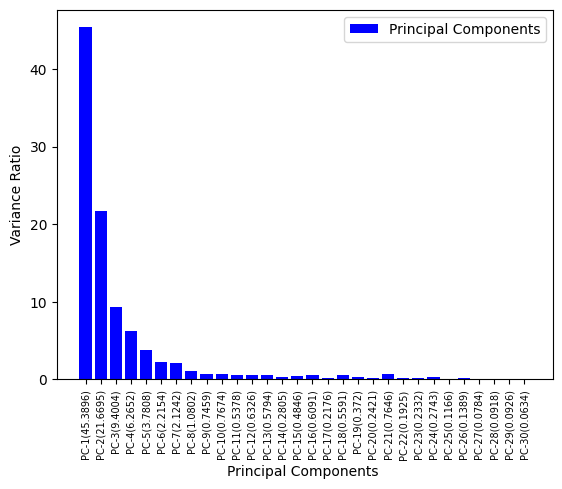

In [228]:
explained_variance = np.var(X_test, axis=0)
ev = explained_variance / np.sum(explained_variance)
#--------- Bar Graph for Explained Variance Ratio ------------
plt.bar([i for i in range(n_components) ],list(ev*100),label='Principal Components',color='b')
plt.legend()
plt.xlabel('Principal Components ')
n=list(ev*100)
pc=[]
for i in range(len(n)):
        n[i]=round(n[i],4)
        pc.append('PC-'+str(i+1)+'('+str(n[i])+')')
plt.xticks([i for i in range(n_components) ],pc, fontsize=7, rotation=90)
plt.ylabel('Variance Ratio')
plt.show()

In [200]:
print("RMSE",root_mean_squared_error(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print("R2 score",r2)

RMSE 0.006354050328566345
MAE 0.004194774029836912
R2 score 0.9995661922908338


In [201]:
X_test, y_test = X2,y2
X_test = kpca.transform(X_test)
y_pred=regr.predict(X_test)

print("RMSE",root_mean_squared_error(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print("R2 score",r2)

RMSE 0.2191653059438948
MAE 0.15507596827734593
R2 score 0.4218143002816651


In [188]:
X_test.shape,y_test.shape,y_pred.shape

((450, 809), (450,), (450,))

In [25]:
import pickle 
pickle.dump(regr, open("regression_in_cylinser2_10_23_after_fft", 'wb')) 

In [45]:
my_model_clf = pickle.load(open("regression_in_cylinser2_10_23_after_fft", 'rb')) 
result_score = my_model_clf.score(X_test,y_test) 
print("Score: ",result_score)
y_pred = my_model_clf.predict(X_test)

Score:  0.9968496246624076


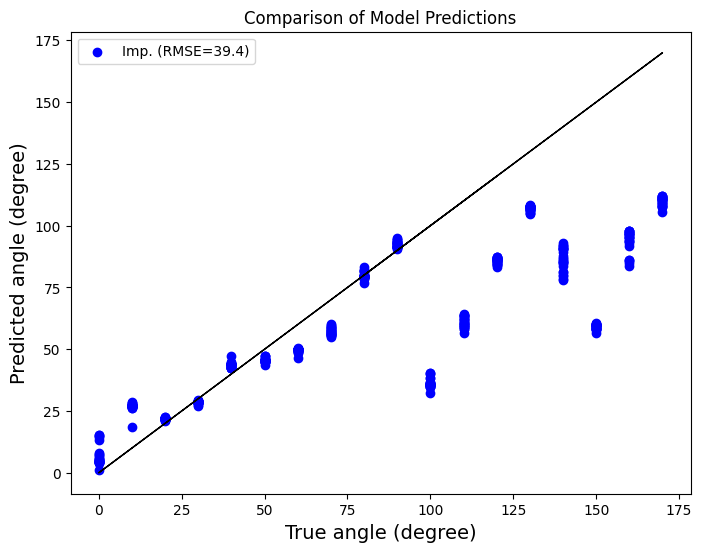

In [202]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test*180, y_pred*180, label=f'Imp. (RMSE={root_mean_squared_error(y_test,y_pred)*180:.1f})', color='blue', marker='o')

# plt.scatter(y_test*180, y_pred*180, label=f'Imp. (RMSE={root_mean_squared_error(y_test,y_pred)*180:.1f})', color='red', marker='o')
# Plot the line of perfect prediction
plt.plot(y_test*180, y_test*180, color='black', linestyle='-', linewidth=1)

# Labels and title
plt.xlabel('True angle (degree)', fontsize=14)
plt.ylabel('Predicted angle (degree)', fontsize=14)
plt.legend(loc='upper left')
plt.title('Comparison of Model Predictions')

# Display the plot
plt.show()

In [207]:
p8750221000

array([0.46247415, 0.46717053, 0.47165043, 0.46720125, 0.46851941,
       0.46974421, 0.47494348, 0.47660361, 0.4789518 , 0.47875256,
       0.48105945, 0.4842944 , 0.48281883, 0.48479799, 0.47908692,
       0.47529939, 0.48049235, 0.47994441, 0.47540673, 0.47973179,
       0.48407772, 0.48130496, 0.48321097, 0.47314408, 0.48339688,
       0.27682759, 0.2775834 , 0.27791923, 0.27850366, 0.2770569 ,
       0.27568386, 0.27782462, 0.27764286, 0.27896967, 0.27869745,
       0.27329274, 0.2780856 , 0.27834019, 0.27278654, 0.27951999,
       0.27565366, 0.27760846, 0.27189677, 0.27756344, 0.27729882,
       0.26906779, 0.25688853, 0.27242167, 0.27470817, 0.2761036 ,
       0.12510711, 0.115604  , 0.12465833, 0.11968875, 0.12079889,
       0.12281584, 0.12297392, 0.1227011 , 0.1198662 , 0.12351509,
       0.12037449, 0.12108992, 0.118013  , 0.12125238, 0.12161015,
       0.12098699, 0.11793753, 0.11804671, 0.12240921, 0.1219186 ,
       0.12290362, 0.12283264, 0.11796648, 0.12351422, 0.12038

In [211]:
y_test=np.array(y_test)

In [212]:
y_test

array([0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.66666667, 0.66666667, 0.66666667, 0.66666667, 0.66666667,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111111,
       0.11111111, 0.11111111, 0.11111111, 0.11111111, 0.11111

In [209]:
p8750

array([0.56117534, 0.60054445, 0.59755761, 0.64554853, 0.57218528,
       0.44139214, 0.58942598, 0.54870474, 0.5633719 , 0.60095578,
       0.62054853, 0.57592537, 0.58552011, 0.61220585, 0.61254052,
       0.67444987, 0.64276429, 0.67630934, 0.68390572, 0.69788063,
       0.65183965, 0.71186355, 0.63009195, 0.71361163, 0.64256912,
       0.34600647, 0.29473106, 0.3142765 , 0.32106226, 0.36699074,
       0.33866939, 0.29887975, 0.3875896 , 0.31572768, 0.35742957,
       0.26526258, 0.35606743, 0.32894879, 0.28978521, 0.37296056,
       0.39011619, 0.39875756, 0.35740478, 0.39690614, 0.38548023,
       0.30828645, 0.24225367, 0.30250279, 0.20629489, 0.24091591,
       0.06827944, 0.07014216, 0.05871777, 0.07132584, 0.05874897,
       0.0523833 , 0.05490895, 0.0483077 , 0.06802194, 0.05448869,
       0.07873682, 0.04183324, 0.08914105, 0.06406809, 0.06844692,
       0.04246077, 0.05265718, 0.04415667, 0.08015163, 0.07786123,
       0.09314192, 0.04313144, 0.0668252 , 0.04292867, 0.04367

In [171]:
full
p8750

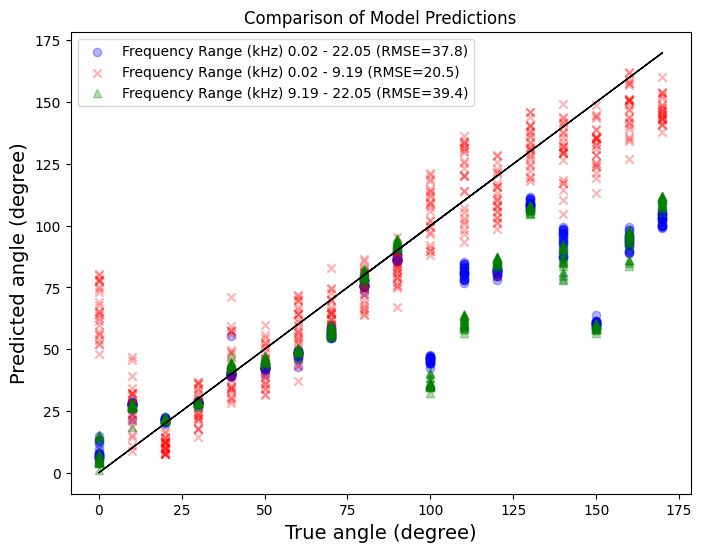

In [206]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test*180, full*180,alpha=0.3, label=f'Frequency Range (kHz) 0.02 - 22.05 (RMSE={root_mean_squared_error(y_test,full)*180:.1f})', color='blue', marker='o')

plt.scatter(y_test*180, p8750*180,alpha=0.3, label=f'Frequency Range (kHz) 0.02 - 9.19 (RMSE={root_mean_squared_error(y_test,p8750)*180:.1f})', color='red', marker='x')
plt.scatter(y_test*180, p8750221000*180,alpha=0.3, label=f'Frequency Range (kHz) 9.19 - 22.05 (RMSE={root_mean_squared_error(y_test,p8750221000)*180:.1f})', color='green', marker='^')
# Plot the line of perfect prediction
plt.plot(y_test*180, y_test*180, color='black', linestyle='-', linewidth=1)

# Labels and title
plt.xlabel('True angle (degree)', fontsize=14)
plt.ylabel('Predicted angle (degree)', fontsize=14)
plt.legend(loc='upper left')
plt.title('Comparison of Model Predictions')

# Display the plot
plt.show()